# Previsão de Churn de Clientes
Este projeto tem como objetivo identificar clientes que têm maior probabilidade de deixar a empresa (churn), utilizando análise exploratória, engenharia de features e modelos de machine learning. O notebook é estruturado para análise completa, desde o entendimento dos dados até a avaliação de modelos.

## Importando módulos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

## Carregando dados

In [3]:
df = pd.read_csv('data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Procurando por valores nulos e NaN

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df = df.drop(['customerID'], axis=1)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [15]:
df = df.drop(labels=df[df['tenure']==0].index, axis=0)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Análise Exploratória

<Axes: xlabel='Churn', ylabel='count'>

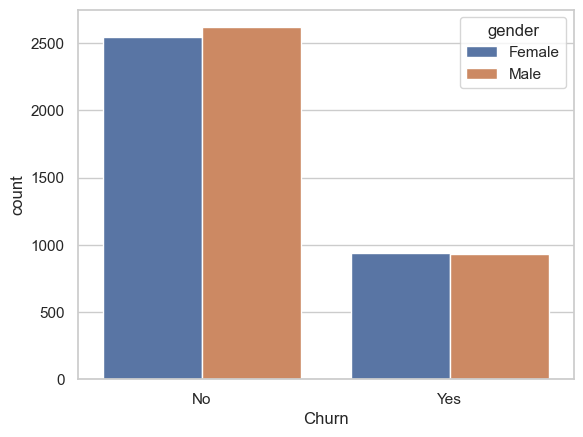

In [17]:
sns.countplot(x='Churn', hue='gender', data=df)

<Axes: xlabel='Churn', ylabel='count'>

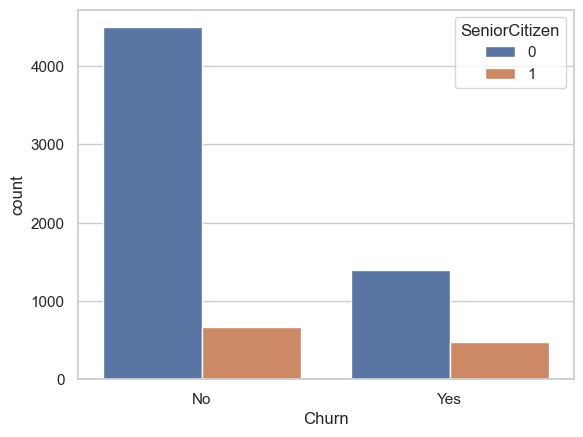

In [18]:
sns.countplot(x='Churn', hue='SeniorCitizen', data=df)

Clientes mais velhos são mais propícios a pararem de usar os serviços

<Axes: xlabel='Churn', ylabel='count'>

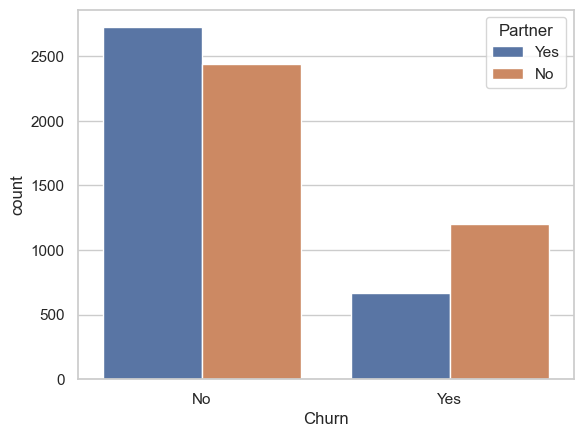

In [19]:
sns.countplot(x='Churn', hue='Partner', data=df)

Pessoas solteiras são mais propícias a pararem de usar os serviços

<Axes: xlabel='Churn', ylabel='count'>

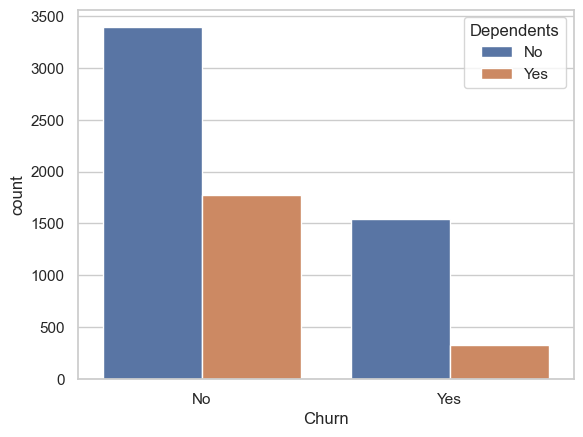

In [21]:
sns.countplot(x='Churn', hue='Dependents', data=df)

Pessoas com filhos são mais propícios a pararem de usar os serviços

<Axes: xlabel='Churn', ylabel='count'>

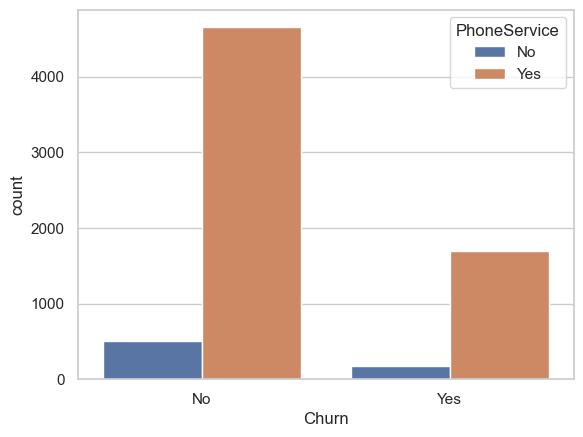

In [22]:
sns.countplot(x='Churn', hue='PhoneService', data=df)

<Axes: xlabel='Churn', ylabel='count'>

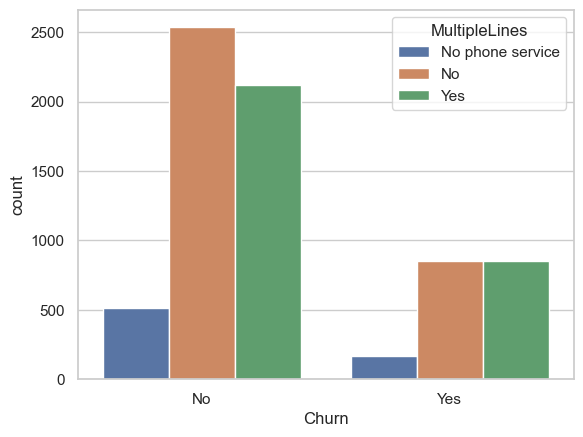

In [23]:
sns.countplot(x='Churn', hue='MultipleLines', data=df)

<Axes: xlabel='Churn', ylabel='count'>

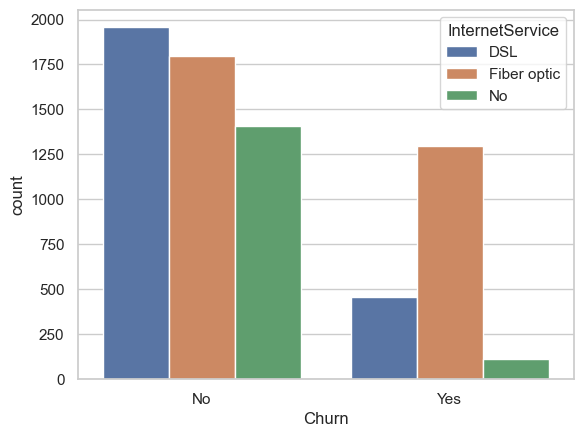

In [24]:
sns.countplot(x='Churn', hue='InternetService', data=df)

Clientes que optaram por fibra ótica costumam cancelar mais, por outro lado, clientes que possuem DSL são mais fiéis

<Axes: xlabel='Churn', ylabel='count'>

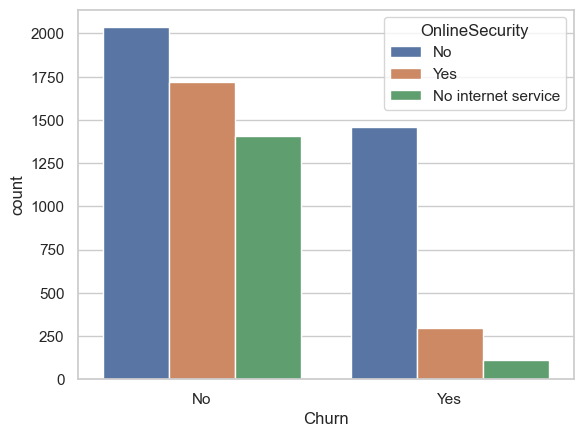

In [26]:
sns.countplot(x='Churn', hue='OnlineSecurity', data=df)

Clientes que não optaram pela segurança online tem grandes chances de cancelar o serviço

<Axes: xlabel='Churn', ylabel='count'>

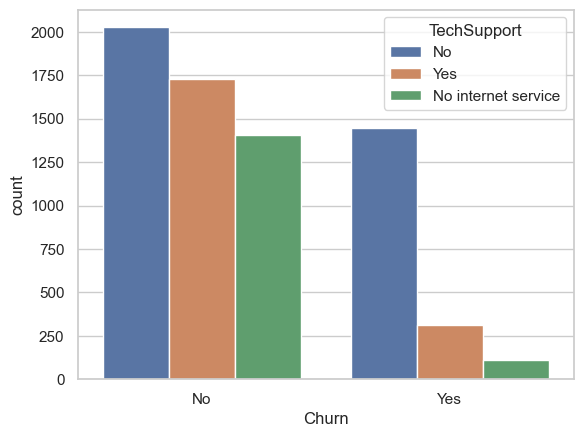

In [28]:
sns.countplot(x='Churn', hue='TechSupport', data=df)

Clientes sem suporte tem grandes chances de cancelar

<Axes: xlabel='Churn', ylabel='count'>

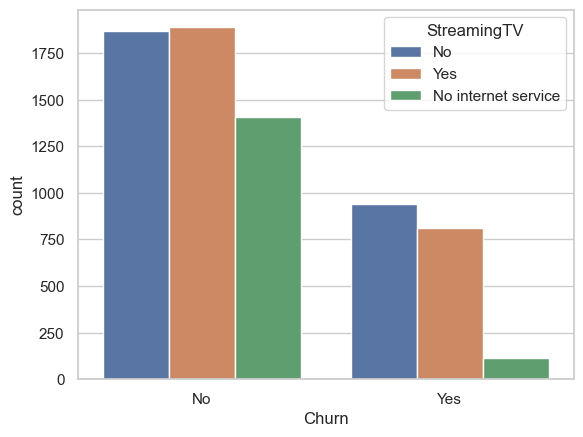

In [29]:
sns.countplot(x='Churn', hue='StreamingTV', data=df)

Curiosamente, ter ou não serviços de streaming não possui grande peso na análise

<Axes: xlabel='Churn', ylabel='count'>

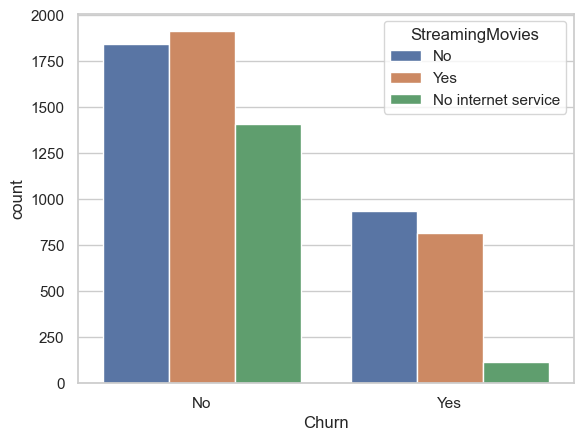

In [31]:
sns.countplot(x='Churn', hue='StreamingMovies', data=df)

O mesmo vale para serviços de streaming de filmes

<Axes: xlabel='Churn', ylabel='count'>

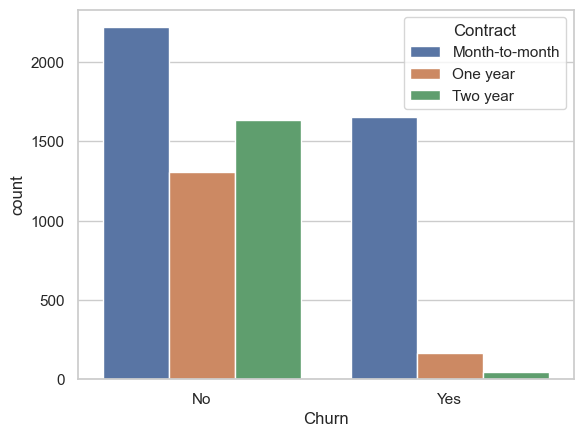

In [32]:
sns.countplot(x='Churn', hue='Contract', data=df)

Clientes que assinam contratos mensais são os principais possuem grandes chances de cancelar os serviços.

<Axes: xlabel='Churn', ylabel='count'>

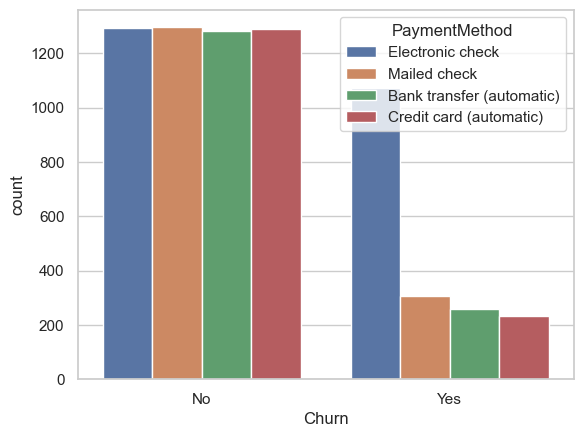

In [34]:
sns.countplot(x='Churn', hue='PaymentMethod', data=df)

Clientes que usam meios eletrônicos são os que mais cancelam os serviços

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

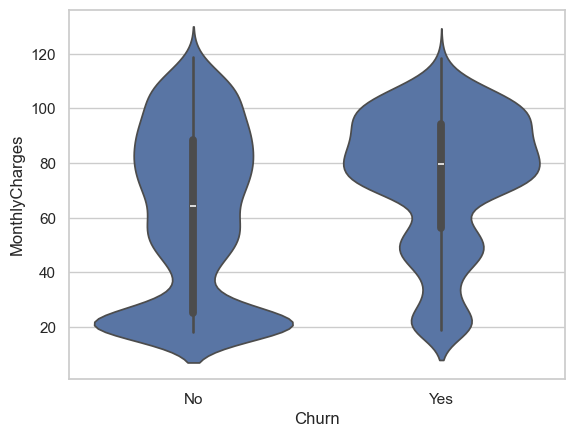

In [38]:
sns.violinplot(x='Churn', y='MonthlyCharges', data=df)

Quanto maior a mensalidade, maior a chance de cancelar

<Axes: xlabel='Churn', ylabel='tenure'>

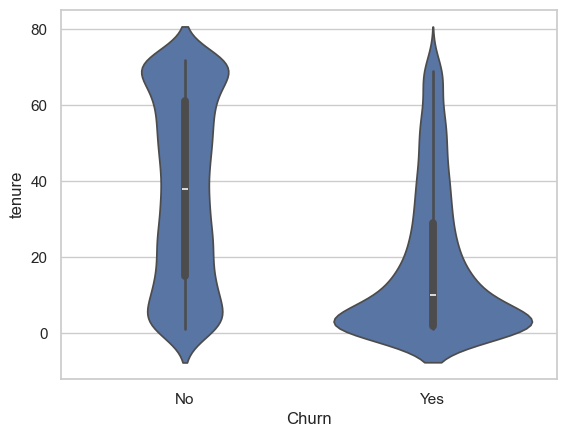

In [41]:
sns.violinplot(x='Churn', y='tenure', data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

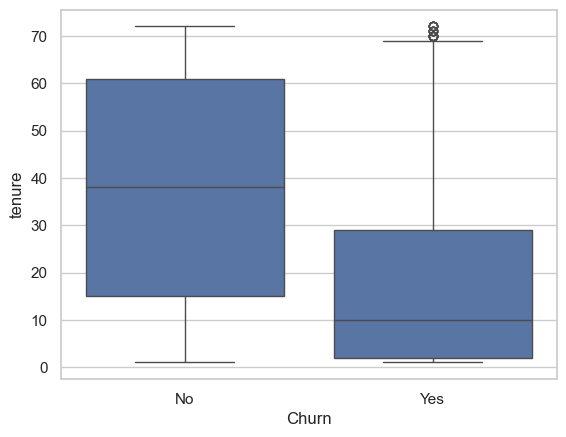

In [42]:
sns.boxplot(x='Churn', y='tenure', data=df)

## Correlações

<Axes: >

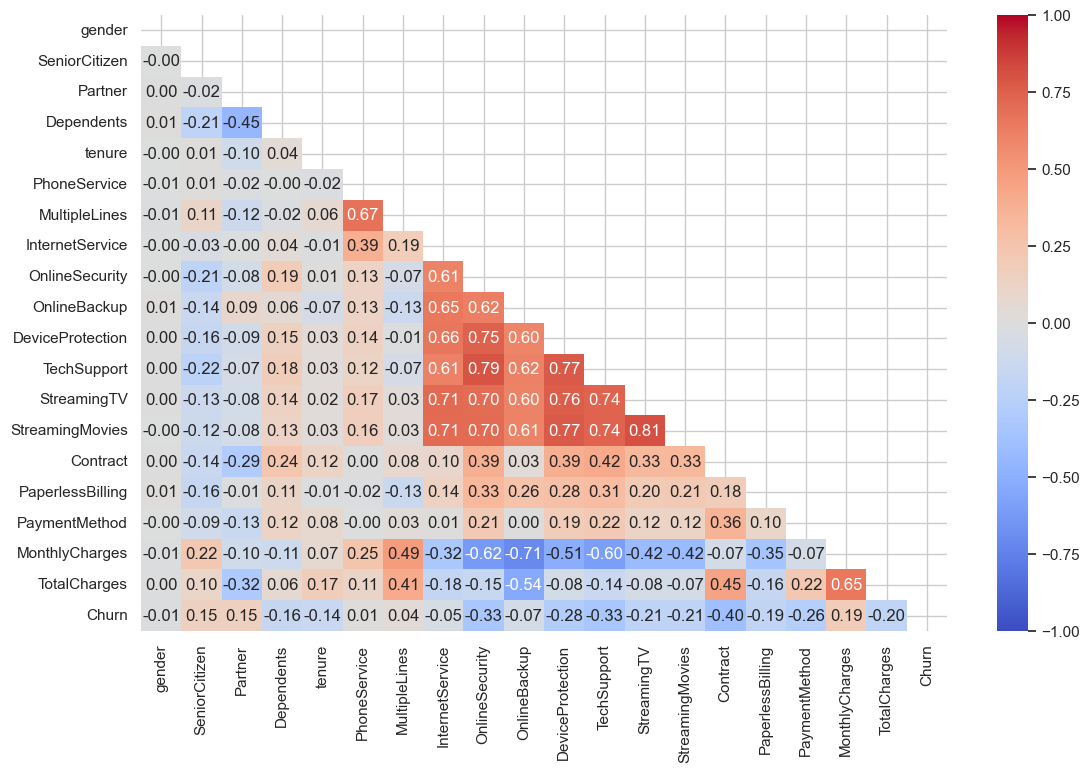

In [47]:
plt.figure(figsize=(13,8))
corr = df.apply(lambda x: pd.factorize(x)[0] if x.dtype!='float64' else x).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0, annot=True, fmt='.2f')

## Pré-processamento

In [50]:
from sklearn.preprocessing import LabelEncoder

cols = [col for col in df.columns if df[col].dtype == 'object']

for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [52]:
df['MonthlyCharges'] = np.log(df['MonthlyCharges'] + 1)
df['TotalCharges'] = np.log(df['TotalCharges'] + 1)

<Axes: xlabel='TotalCharges', ylabel='Density'>

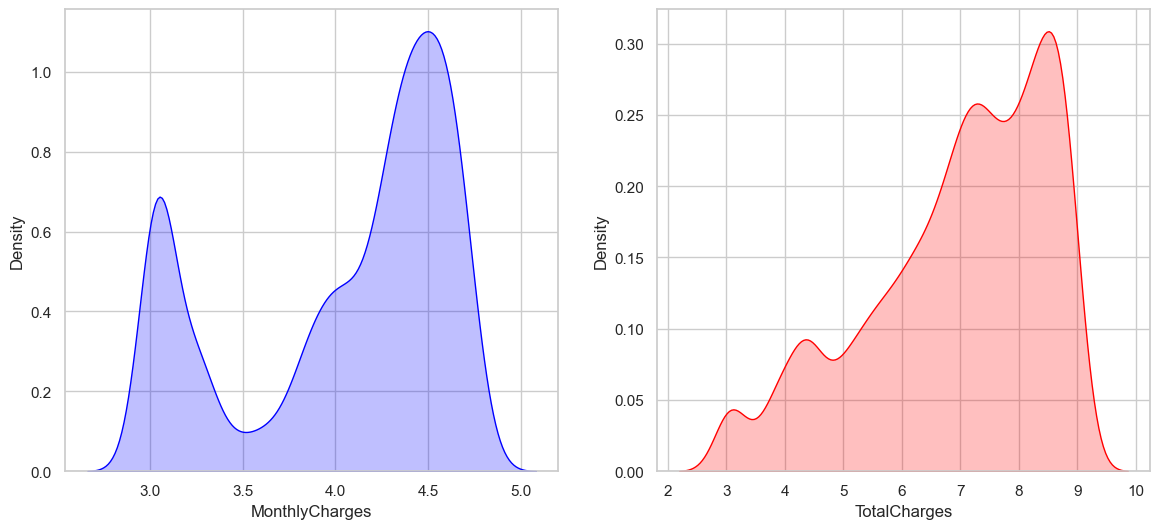

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.kdeplot(df['MonthlyCharges'], ax=axes[0], color='blue', shade=True)
sns.kdeplot(df['TotalCharges'], ax=axes[1], color='red', shade=True)

### Train Test Split

In [59]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Treinando o modelo

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [63]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Confusion Matrix

<Axes: >

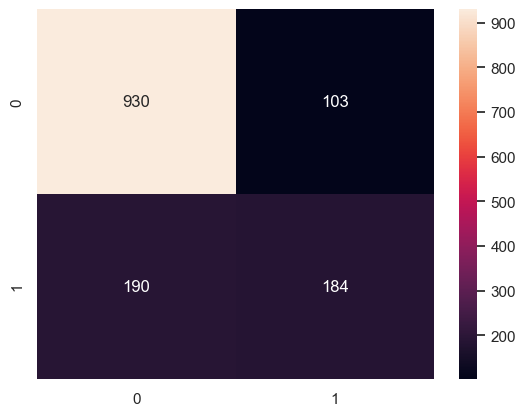

In [64]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

## Salvando CSV para uso posterior no PowerBI

In [67]:
df_final = df.copy()

# Prevendo todos os valores dessa vez
X_total = df_final.drop(columns=['Churn'])
previsoes_totais = model.predict(X_total)

df_final['Previsao_Churn'] = previsoes_totais

probabilidades = model.predict_proba(X_total)[:, 1]
df_final['Probabilidade_Churn'] = probabilidades

df_final.to_csv('dados_churn_powerbi.csv', index=False, sep=';', encoding='utf-8')

In [68]:
df_final.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Previsao_Churn,Probabilidade_Churn
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,1,2,3.429137,3.429137,0,0,0.21
1,1,0,0,0,34,1,0,0,2,0,...,0,0,1,0,3,4.059581,7.544597,0,0,0.02
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,4.004602,4.692723,1,1,0.74
3,1,0,0,0,45,0,1,0,2,0,...,0,0,1,0,0,3.768153,7.518471,0,0,0.00
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,4.272491,5.028148,1,1,0.69
